<a href="https://colab.research.google.com/github/zFonta/CEIA-TF-Chess-DL/blob/main/notebooks/05_hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 - Ajuste de hiperparámetros y segunda campaña

Tareas **4.5** (ajuste y experimentación) y **4.6** (segunda campaña con la
configuración optimizada) del WBS.

**De dónde salen los experimentos.** No es un barrido a ciegas: la primera
campaña ya acotó el espacio, y cada configuración cuesta horas de GPU sobre
un presupuesto fijo de Colab.

| Lo que mostró la campaña 1 | Lo que implica |
|---|---|
| Sobreajusta desde la época 14: la pérdida de entrenamiento cayó 42 % y la validación no se movió | El margen está en **regularización**, no en capacidad ni en más épocas |
| Picos de validación en las épocas 2, 4 y 10 con el LR cerca del máximo | Probar **calentamiento** del learning rate |


**Referencias a batir:** piso de material 0,3973 · campaña 1 en validación **0,2584**.


## 1. Entorno


In [1]:
# Clonar el repositorio e instalar el paquete.
# Idempotente: se puede volver a correr tal cual despues de una desconexion.
import os, sys, subprocess, importlib
from pathlib import Path

REPO_DIR = Path("/content/CEIA-TF-Chess-DL")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/zFonta/CEIA-TF-Chess-DL.git", str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], check=True)

# pip registra el paquete editable con un .pth, y los .pth solo se procesan al
# arrancar el interprete: un kernel que ya esta corriendo no lo ve. Agregar src/
# a sys.path lo hace visible sin tener que reiniciar el runtime.
src = str(REPO_DIR / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()

# Stockfish con version fija. Entrenar no lo usa, pero sin el se saltean los 17
# tests de integracion del pipeline, que son la evidencia del requerimiento 3.2.
subprocess.run(["bash", "scripts/setup_stockfish.sh"], check=True)
os.environ["PATH"] = f"{REPO_DIR}/bin:" + os.environ["PATH"]

print("Listo. Directorio de trabajo:", os.getcwd())

Listo. Directorio de trabajo: /content/CEIA-TF-Chess-DL


In [2]:
import numpy as np
import torch
from chessdl.colab import TRAINING, describe_runtime

runtime = describe_runtime(phase=TRAINING)
print("GPU  :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU")
for aviso in runtime.warnings():
    print("AVISO:", aviso)

GPU  : Tesla T4


## 2. Tests


In [3]:
!{sys.executable} -m pytest -q

........................................................................ [ 20%]
........................................................................ [ 41%]
........................................................................ [ 61%]
........................................................................ [ 82%]
.............................................................            [100%]
349 passed in 55.79s


## 3. Dataset, partición, caché y pisos

Idéntico a la notebook 04. Si el caché ya está en disco no se reconstruye.


In [4]:
from chessdl.config import load_config
from chessdl import hf
from chessdl.data import schema
from chessdl.training.split import describe_split, leaked_games, split_masks
from chessdl.training.cache import build_cache, cache_path_for, load_cache
from chessdl.training.baselines import material_baseline, mean_baseline

cfg = load_config()
token = hf.get_token()
directorio = hf.download_dataset(cfg.output.hf_repo_id, "/content/ceia-chess/hub")
tabla = schema.read_dataset(schema.shard_paths(directorio))

fens     = tabla["fen"].to_pylist()
game_ids = tabla["game_id"].to_pylist()
targets  = np.asarray(tabla["value_stm"], dtype=np.float32)

split_cfg = cfg.training.split_config()
masks = split_masks(game_ids, split_cfg)
assert not leaked_games(masks, game_ids)

ruta_cache = cache_path_for(cfg.training.cache_dir)
if not ruta_cache.exists():
    build_cache(fens, ruta_cache, progress=True)
cache = load_cache(ruta_cache, expected_rows=len(fens))

idx_train = np.flatnonzero(masks['train'])
idx_val   = np.flatnonzero(masks['val'])
idx_test  = np.flatnonzero(masks['test'])

rng = np.random.default_rng(0)
sub = np.sort(rng.choice(idx_train, size=min(200_000, len(idx_train)), replace=False))
media = mean_baseline(targets[idx_train], targets[idx_val])
material, _ = material_baseline(np.asarray(cache[sub]), targets[sub],
                                np.asarray(cache[idx_val]), targets[idx_val])
pisos = {'media': media.rmse, 'material': material.rmse}
print(media); print(material)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 158 files:   0%|          | 0/158 [00:00<?, ?it/s]

encoding:   0%|          | 0/2552804 [00:00<?, ?pos/s]

media constante             RMSE 0.4886   MAE 0.3778
material (lineal)           RMSE 0.3973   MAE 0.3052


## 4. El barrido (tarea 4.5)

Cinco brazos. `base` es el control —la misma configuración de la campaña 1
pero con el coseno sobre el presupuesto corto— y no es una corrida
desperdiciada: anelar a cero en 15 épocas es una trayectoria distinta y mejor
terminada que frenar una de 30, y sin ella los otros cuatro no tienen contra
qué compararse al mismo presupuesto.

Si se quiere recortar costo, sacar un brazo de la tupla o bajar `EPOCAS_BARRIDO`.

> **Es reanudable.** Cada brazo tiene su propio nombre de corrida en el Hub.
> Si Colab corta a mitad del barrido, se vuelve a correr esta celda: los
> brazos terminados se detectan y se saltean, y el que quedó a medias sigue
> desde su última época.


In [5]:
from chessdl.training.experiments import DEFAULT_SWEEP, run_sweep

for e in DEFAULT_SWEEP:
    print(f'{e.name:<10}{e.rationale}')

base      control: la configuracion de la campana 1, con coseno corto
wd-alto   weight decay x10, contra el sobreajuste desde la epoca 14
dropout   dropout en la cabeza, donde se concentran los parametros densos
warmup    calentamiento lineal, contra los picos de las epocas 2, 4 y 10
huber     perdida robusta: el 1,43 % de mates saturados domina el gradiente con MSE


In [6]:
from chessdl.models.resnet import ResNetConfig

EPOCAS_BARRIDO = 15
REFERENCIA = 0.2584   # mejor validacion de la campana 1

arquitectura = ResNetConfig(channels=128, blocks=8)
repo_modelos = f'{cfg.output.hf_namespace}/{cfg.training.hf_models_repo}'

barrido = run_sweep(
    DEFAULT_SWEEP, cache, targets, idx_train, idx_val,
    base_model=arquitectura,
    repo_id=repo_modelos,
    local_dir='/content/ceia-chess/checkpoints',
    token=token,
    push_to_hub=cfg.training.push_to_hub and token is not None,
    epochs=EPOCAS_BARRIDO,
    prefix='sweep',
    batch_size=cfg.training.batch_size,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    loss_name=cfg.training.loss,
    seed=cfg.training.split_seed,
    baselines=pisos,
    reference=REFERENCIA,
)


sweep-base: control: la configuracion de la campana 1, con coseno corto


epoca 1:   0%|          | 0/2244 [00:00<?, ?lote/s]

epoca   1  perdida 0.12825  RMSE 0.5282  MAE 0.4171  MAEcp  235.7  signo 64.0%  rho 0.5373


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...-huber/checkpoint_last.pt:   0%|          |  123kB / 35.1MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...-huber/checkpoint_best.pt:  57%|#####7    | 20.1MB / 35.1MB            

## 5. Resultados del barrido


In [7]:
print(barrido.table())

experimento   val RMSE   MAE cp   signo     rho  epoca   que cambia
--------------------------------------------------------------------------------------------
warmup          0.2429    103.0   88.4%  0.8478     15 * calentamiento lineal, contra los picos de las epocas 2, 4 y 10
dropout         0.2607    113.5   86.3%  0.8200     15   dropout en la cabeza, donde se concentran los parametros densos
huber           0.2613    106.1   87.4%  0.8269     15   perdida robusta: el 1,43 % de mates saturados domina el gradiente con MSE
wd-alto         0.2616    112.8   86.4%  0.8188     15   weight decay x10, contra el sobreajuste desde la epoca 14
base            0.2620    113.3   86.2%  0.8176     15   control: la configuracion de la campana 1, con coseno corto

* mejor: warmup (val RMSE 0.2429)
  contra la campana 1 (0.2584): mejora 6.00%
  contra el piso de material (0.3973): mejora 38.9%


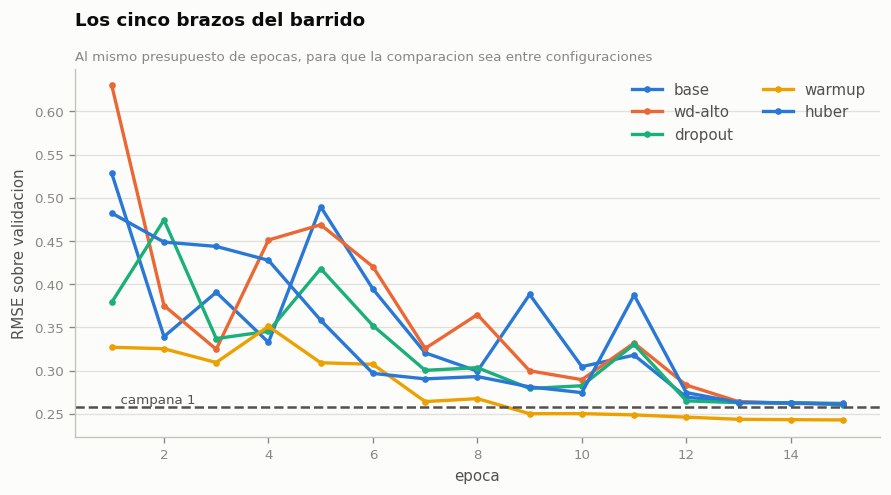

In [8]:
import matplotlib.pyplot as plt
from chessdl import viz

viz.apply_style()
fig, ax = plt.subplots()
for i, (nombre, run) in enumerate(barrido.runs.items()):
    ep = [e.epoch for e in run.history.epochs]
    ax.plot(ep, [e.val_rmse for e in run.history.epochs],
            marker='o', markersize=3, color=viz.SERIES[i % len(viz.SERIES)], label=nombre)
ax.axhline(REFERENCIA, color=viz.INK_SECONDARY, linestyle='--', linewidth=1.5)
ax.text(1, REFERENCIA, '  campana 1', color=viz.INK_SECONDARY, fontsize=8, va='bottom')
ax.legend(loc='upper right', ncol=2)
viz.label_axes(ax, 'Los cinco brazos del barrido', 'epoca', 'RMSE sobre validacion',
               note='Al mismo presupuesto de epocas, para que la comparacion sea entre configuraciones')
fig.tight_layout()

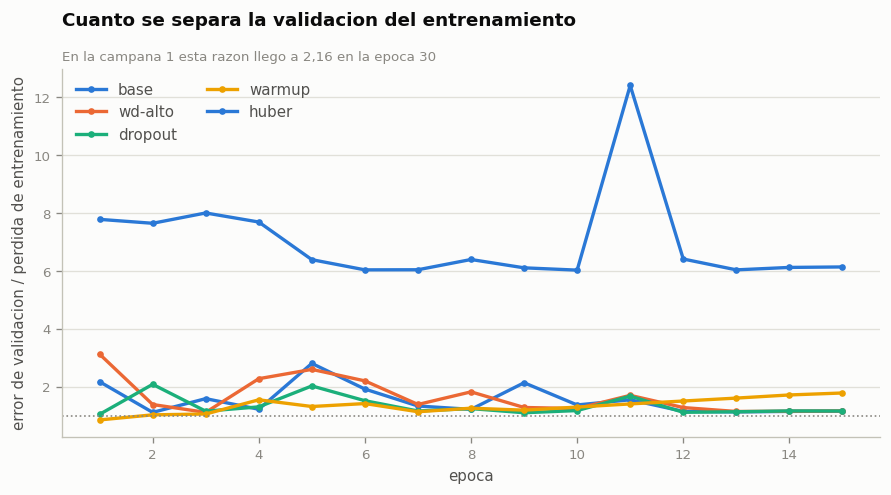

In [9]:
# El sobreajuste, que es lo que el barrido intenta atacar.
fig, ax = plt.subplots()
for i, (nombre, run) in enumerate(barrido.runs.items()):
    ep  = [e.epoch for e in run.history.epochs]
    raz = [e.val_rmse ** 2 / e.train_loss for e in run.history.epochs]
    ax.plot(ep, raz, marker='o', markersize=3, color=viz.SERIES[i % len(viz.SERIES)], label=nombre)
ax.axhline(1.0, color=viz.INK_MUTED, linestyle=':', linewidth=1)
ax.legend(loc='upper left', ncol=2)
viz.label_axes(ax, 'Cuanto se separa la validacion del entrenamiento', 'epoca',
               'error de validacion / perdida de entrenamiento',
               note='En la campana 1 esta razon llego a 2,16 en la epoca 30')
fig.tight_layout()

## 6. Segunda campaña (tarea 4.6)

El ganador del barrido, ahora a **30 épocas**.

Por qué se confirma en vez de adoptarse directo: **cribar regularización con
presupuesto corto no es neutral.** Menos entrenamiento favorece a menos
regularización, así que un `weight_decay` o un dropout que gane a 15 épocas
puede quedarse corto a 30. La tabla del barrido ordena candidatos; el número
que va a la memoria sale de esta campaña.


In [10]:
from chessdl.training.loop import seed_everything
from chessdl.models.resnet import ChessResNet
from chessdl.training.checkpoint import HubCheckpoints
from chessdl.training.loop import train

EPOCAS_FINAL = 30

ganador = barrido.experiments[barrido.best_name()]
print(f'Ganador del barrido: {ganador.name} -- {ganador.rationale}')
print(f'Cambia: {ganador.overrides()}' + (f" + dropout {ganador.dropout}" if ganador.dropout else ''))

config_final = ganador.model_config(arquitectura)
# La siembra va ANTES de construir el modelo: train() tambien siembra,
# pero para entonces los pesos iniciales ya salieron del estado en que
# estuviera el interprete, y no serian reproducibles entre sesiones.
seed_everything(cfg.training.split_seed)
modelo = ChessResNet(config_final)
print(modelo.describe())

Ganador del barrido: warmup -- calentamiento lineal, contra los picos de las epocas 2, 4 y 10
Cambia: {'warmup_epochs': 2}
ResNet 128 canales x 8 bloques (cabeza 32/256) -- 2,913,345 parametros


In [11]:
checkpoints = HubCheckpoints(
    repo_id=repo_modelos,
    run_name=f'campana2-{ganador.name}',
    local_dir='/content/ceia-chess/checkpoints',
    token=token,
    enabled=cfg.training.push_to_hub and token is not None,
)

ajustes = dict(
    epochs=EPOCAS_FINAL,
    batch_size=cfg.training.batch_size,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    loss_name=cfg.training.loss,
    seed=cfg.training.split_seed,
)
ajustes.update(ganador.overrides())
ajustes['epochs'] = EPOCAS_FINAL   # el presupuesto lo fija la campana, no el brazo

campana2 = train(
    modelo, cache, targets, idx_train, idx_val,
    checkpoints=checkpoints,
    model_config={'channels': config_final.channels, 'blocks': config_final.blocks,
                  'dropout': config_final.dropout},
    baselines=pisos,
    **ajustes,
)
print()
print(campana2.summary())

epoca 1:   0%|          | 0/2244 [00:00<?, ?lote/s]

epoca   1  perdida 0.12507  RMSE 0.3271  MAE 0.2413  MAEcp  148.2  signo 78.6%  rho 0.7021


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...warmup/checkpoint_last.pt:  45%|####5     | 15.9MB / 35.1MB            

...

epoca  30  perdida 0.01721  RMSE 0.2539  MAE 0.1597  MAEcp  105.9  signo 88.1%  rho 0.8379


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...warmup/checkpoint_last.pt:   1%|          |  232kB / 35.1MB            


 epoca     train   val RMSE   val MAE   MAE cp    signo     rho     seg
-----------------------------------------------------------------------
     1   0.12507     0.3271    0.2413    148.2   78.6%  0.7021     228
     2   0.10254     0.3253    0.2411    147.1   78.0%  0.7152     226
     3   0.09028     0.3094    0.2246    137.8   79.9%  0.7426     226
     4   0.07970     0.3802    0.2867    164.7   72.6%  0.7171     225
     5   0.07278     0.3641    0.2681    158.3   74.5%  0.7460     225
     6   0.06727     0.2658    0.1792    115.1   85.9%  0.8141     225
     7   0.06273     0.2711    0.1901    120.0   84.3%  0.8209     225
     8   0.05908     0.2650    0.1788    114.9   85.2%  0.8158     224
     9   0.05574     0.2889    0.1994    124.8   84.5%  0.7877     224
    10   0.05267     0.2611    0.1743    112.3   86.1%  0.8325     223
    11   0.04955     0.2626    0.1819    116.2   84.6%  0.8328     224
    12   0.04677     0.3027    0.2136    131.4   81.8%  0.8125     224
   

## 7. Evaluación final sobre test

El split de test se toca **una sola vez**, con el mejor checkpoint por
validación de esta segunda campaña.


In [12]:
from chessdl.training.checkpoint import BEST_NAME, load_checkpoint
from chessdl.training.loop import evaluate_split

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
mejor = checkpoints.fetch(BEST_NAME)
if mejor is not None:
    load_checkpoint(mejor, modelo, map_location=dispositivo)
modelo = modelo.to(dispositivo)

test2 = evaluate_split(modelo, cache, targets, idx_test, dispositivo)
print('TEST -- campana 2')
print(test2.summary())

campana2-warmup/checkpoint_best.pt: reconstructing file:   0%|          |  0.00B / 35.1MB            

campana2-warmup/checkpoint_best.pt: downloading bytes:           |  0.00B            

TEST -- campana 2
posiciones                     127,499
RMSE (value)                    0.2511
MAE (value)                     0.1600
MAE (centipeones)                105.8
acuerdo de signo               87.80%
Spearman                        0.8385


## 8. Resumen: qué ganó el ajuste


In [13]:
TEST_CAMPANA1 = 0.2609   # RMSE de test de la notebook 04

print(f"{'':<34}{'RMSE':>10}{'R2':>10}")
print('-' * 56)
for nombre, valor in [('media constante', pisos['media']),
                      ('material lineal', pisos['material']),
                      ('ResNet campana 1 (test)', TEST_CAMPANA1),
                      ('ResNet campana 2 (test)', test2.rmse)]:
    print(f"{nombre:<34}{valor:>10.4f}{1-(valor/pisos['media'])**2:>10.3f}")
print()
delta = (TEST_CAMPANA1 - test2.rmse) / TEST_CAMPANA1
print(f"El ajuste {'mejoro' if delta > 0 else 'EMPEORO'} el test un {abs(delta):.2%}.")
if abs(delta) < 0.01:
    print('Menos del 1 %: el ajuste de hiperparametros no es donde estaba el margen.')
    print('Eso tambien es un resultado, y apunta a los datos como siguiente palanca:')
    print('se consumio el 47 % del extracto, y el ruido de etiqueta explica <5 % del error.')
print()
print(f'Pesos y metricas: https://huggingface.co/{repo_modelos}')

                                        RMSE        R2
--------------------------------------------------------
media constante                       0.4886     0.000
material lineal                       0.3973     0.339
ResNet campana 1 (test)               0.2609     0.715
ResNet campana 2 (test)               0.2511     0.736

El ajuste mejoro el test un 3.74%.

Pesos y metricas: https://huggingface.co/zFonta/ceia-chess-models
